# Early Product Success Prediction: Logistic Regression vs Final Text-Enhanced XGBoost

This notebook compares the original Logistic Regression baseline against the newest tuned XGBoost model with sentiment and TF-IDF/SVD text features. Both models are evaluated on the same train/test split so that metric differences reflect model/features rather than different data partitions.


In [1]:
# ==========================================
# Imports and config
# ==========================================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix, issparse

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from textblob import TextBlob

warnings.filterwarnings("ignore")

SAMPLES_DIR = Path("samples")
FOUR_WEEKS_DAYS = 28
TOP_PCT = 0.10
TEST_SIZE = 0.20
RANDOM_SEED = 42
SUCCESS_LABEL_NAME = "success_top10"


In [2]:
# ==========================================
# Cell 3 — Helper functions
# ==========================================
def safe_numeric_vote(series: pd.Series) -> pd.Series:
    """
    Convert strings like '1,234' to numeric vote counts.
    Missing values become 0.
    """
    return (
        series.fillna("0")
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace({"": "0", "nan": "0", "None": "0"})
        .pipe(pd.to_numeric, errors="coerce")
        .fillna(0)
    )


def precision_at_k(y_true, y_score, k: int) -> float:
    """
    Precision among the top-k highest-scoring predictions.
    """
    if k <= 0:
        return np.nan
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    order = np.argsort(-y_score)
    top_k = y_true[order][:k]
    return float(np.mean(top_k))


def build_product_features_from_reviews(df_reviews: pd.DataFrame, category_name: str) -> pd.DataFrame:
    """
    Build product-level features using only the first 4 weeks of reviews
    after the first observed review for each product.
    """
    df = df_reviews.copy()

    # Numeric conversions
    df["unixReviewTime"] = pd.to_numeric(df["unixReviewTime"], errors="coerce")
    df["overall"] = pd.to_numeric(df["overall"], errors="coerce")

    if "vote" in df.columns:
        df["vote_num"] = safe_numeric_vote(df["vote"])
    else:
        df["vote_num"] = 0.0

    if "verified" in df.columns:
        df["verified_num"] = df["verified"].fillna(False).astype(int)
    else:
        df["verified_num"] = 0

    if "reviewText" in df.columns:
        df["review_text_len"] = df["reviewText"].fillna("").astype(str).str.len()
    else:
        df["review_text_len"] = 0

    if "summary" in df.columns:
        df["summary_len"] = df["summary"].fillna("").astype(str).str.len()
    else:
        df["summary_len"] = 0

    # Drop rows missing key identifiers or timestamps
    df = df.dropna(subset=["asin", "unixReviewTime", "overall"]).copy()

    # Sort within product
    df = df.sort_values(["asin", "unixReviewTime"]).reset_index(drop=True)

    # Relative time from first observed review
    first_time = df.groupby("asin")["unixReviewTime"].transform("min")
    df["days_since_first"] = (df["unixReviewTime"] - first_time) / (24 * 60 * 60)

    # Restrict to first 4 weeks
    df_4w = df[df["days_since_first"] <= FOUR_WEEKS_DAYS].copy()

    # Review sequence number within first 4 weeks
    df_4w["review_order"] = df_4w.groupby("asin").cumcount() + 1

    grp = df_4w.groupby("asin", sort=False)

    # Aggregate features
    features = grp.agg(
        n_reviews_4w=("overall", "size"),
        mean_rating_4w=("overall", "mean"),
        std_rating_4w=("overall", "std"),
        min_rating_4w=("overall", "min"),
        max_rating_4w=("overall", "max"),
        median_rating_4w=("overall", "median"),
        verified_ratio_4w=("verified_num", "mean"),
        mean_vote_4w=("vote_num", "mean"),
        sum_vote_4w=("vote_num", "sum"),
        mean_review_text_len_4w=("review_text_len", "mean"),
        mean_summary_len_4w=("summary_len", "mean"),
        first_4w_day_span=("days_since_first", "max"),
    ).reset_index()

    def rating_slope(sub: pd.DataFrame) -> float:
        x = sub["days_since_first"].to_numpy(dtype=float)
        y = sub["overall"].to_numpy(dtype=float)
        if len(x) < 2 or np.allclose(x, x[0]):
            return 0.0
        return float(np.polyfit(x, y, 1)[0])

    def review_velocity_slope(sub: pd.DataFrame) -> float:
        x = sub["days_since_first"].to_numpy(dtype=float)
        y = sub["review_order"].to_numpy(dtype=float)
        if len(x) < 2 or np.allclose(x, x[0]):
            return 0.0
        return float(np.polyfit(x, y, 1)[0])

    def late_minus_early_rating(sub: pd.DataFrame) -> float:
        sub = sub.sort_values("days_since_first")
        midpoint = FOUR_WEEKS_DAYS / 2

        early = sub.loc[sub["days_since_first"] <= midpoint, "overall"]
        late = sub.loc[sub["days_since_first"] > midpoint, "overall"]

        if len(early) == 0 or len(late) == 0:
            return 0.0

        return float(late.mean() - early.mean())

    slopes = grp.apply(
        lambda sub: pd.Series({
            "rating_slope_4w": rating_slope(sub),
            "review_velocity_slope_4w": review_velocity_slope(sub),
            "late_minus_early_rating_4w": late_minus_early_rating(sub),
        })
    ).reset_index()

    features = features.merge(slopes, on="asin", how="left")

    # Derived features
    features["reviews_per_day_4w"] = features["n_reviews_4w"] / FOUR_WEEKS_DAYS
    features["vote_per_review_4w"] = features["sum_vote_4w"] / features["n_reviews_4w"].clip(lower=1)
    features["category"] = category_name

    fill_zero_cols = [
        "std_rating_4w",
        "rating_slope_4w",
        "review_velocity_slope_4w",
        "late_minus_early_rating_4w",
    ]
    for col in fill_zero_cols:
        features[col] = features[col].fillna(0.0)

    return features


def build_success_labels(df_reviews: pd.DataFrame, top_pct: float = 0.10) -> pd.DataFrame:
    """
    Label the top X% of products within a category as successful,
    based on lifetime review count.
    """
    df = df_reviews.copy()
    df["overall"] = pd.to_numeric(df["overall"], errors="coerce")
    df["unixReviewTime"] = pd.to_numeric(df["unixReviewTime"], errors="coerce")
    df = df.dropna(subset=["asin", "unixReviewTime", "overall"]).copy()

    lifetime = (
        df.groupby("asin")
        .agg(
            total_reviews_lifetime=("overall", "size"),
            lifetime_mean_rating=("overall", "mean"),
            first_review_time=("unixReviewTime", "min"),
            last_review_time=("unixReviewTime", "max"),
        )
        .reset_index()
        .sort_values("total_reviews_lifetime", ascending=False)
        .reset_index(drop=True)
    )

    n_products = len(lifetime)
    n_top = max(1, int(np.ceil(top_pct * n_products)))

    lifetime[SUCCESS_LABEL_NAME] = 0
    lifetime.loc[:n_top - 1, SUCCESS_LABEL_NAME] = 1

    return lifetime


def evaluate_model(y_true, y_proba, threshold: float = 0.5) -> dict:
    """
    Compute a standard set of binary classification metrics.
    """
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    y_pred = (y_proba >= threshold).astype(int)

    k = int(np.sum(y_true))

    return {
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Average Precision": average_precision_score(y_true, y_proba),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision@K": precision_at_k(y_true, y_proba, k),
        "Test Positive Rate": float(np.mean(y_true)),
        "K used for Precision@K": int(k),
    }


def metrics_dict_to_df(metrics_dict: dict, model_name: str) -> pd.DataFrame:
    """
    Convert metrics dict to a display-friendly dataframe.
    """
    return pd.DataFrame({
        "metric": list(metrics_dict.keys()),
        model_name: list(metrics_dict.values())
    })


def compute_category_metrics(test_df: pd.DataFrame, category_col: str = "category") -> pd.DataFrame:
    """
    Compute evaluation metrics by category.
    Expects columns: category, y_true, y_proba, y_pred
    """
    rows = []

    for category, sub in test_df.groupby(category_col):
        if sub["y_true"].nunique() < 2:
            continue

        rows.append({
            "category": category,
            "n_products": len(sub),
            "positive_rate": sub["y_true"].mean(),
            "roc_auc": roc_auc_score(sub["y_true"], sub["y_proba"]),
            "avg_precision": average_precision_score(sub["y_true"], sub["y_proba"]),
            "precision": precision_score(sub["y_true"], sub["y_pred"], zero_division=0),
            "recall": recall_score(sub["y_true"], sub["y_pred"], zero_division=0),
            "f1": f1_score(sub["y_true"], sub["y_pred"], zero_division=0),
        })

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)

## 1. Build product-level tabular dataset

Only the columns needed for this task are loaded from each category parquet file. The tabular features are created from the first 4 weeks of review activity, while the success label is based on the top 10% of products within each category.


In [3]:
# ==========================================
# Cell 4 — Build the product-level dataset
# ==========================================
all_product_rows = []

category_dirs = sorted([d for d in SAMPLES_DIR.iterdir() if d.is_dir()])

print(f"Found {len(category_dirs)} category folders")

for category_dir in category_dirs:
    file_path = category_dir / "sample_reviews.parquet"
    category_name = category_dir.name

    if not file_path.exists():
        print(f"Skipping {category_name}: sample_reviews.parquet not found")
        continue

    print(f"Loading category: {category_name}")

    needed_cols = [
        "asin",
        "overall",
        "unixReviewTime",
        "reviewText",
        "summary",
        "verified",
        "vote",
    ]

    df_reviews = pd.read_parquet(file_path, columns=needed_cols)

    features = build_product_features_from_reviews(df_reviews, category_name=category_name)
    labels = build_success_labels(df_reviews, top_pct=TOP_PCT)

    category_product_df = features.merge(labels, on="asin", how="inner")
    all_product_rows.append(category_product_df)

product_df = pd.concat(all_product_rows, ignore_index=True)

print("Final product-level dataset shape:", product_df.shape)
product_df.head()

,asin,n_reviews_4w,mean_rating_4w,std_rating_4w,min_rating_4w,max_rating_4w,median_rating_4w,verified_ratio_4w,mean_vote_4w,sum_vote_4w,...,review_velocity_slope_4w,late_minus_early_rating_4w,reviews_per_day_4w,vote_per_review_4w,category,total_reviews_lifetime,lifetime_mean_rating,first_review_time,last_review_time,success_top10
0,5120053351,6,5.0,0.00000,5.0,5.0,5.0,0.50,11.166667,67,...,0.154286,0.000000,0.214286,11.166667,"Clothing, Shoes and Jewelry",52,4.000000,1453507200,1520294400,0
1,5120053890,4,4.5,0.57735,4.0,5.0,4.5,0.25,1.500000,6,...,0.140397,-0.666667,0.142857,1.500000,"Clothing, Shoes and Jewelry",34,4.588235,1465516800,1522713600,0
2,B00001W0GC,1,5.0,0.00000,5.0,5.0,5.0,1.00,0.000000,0,...,0.000000,0.000000,0.035714,0.000000,"Clothing, Shoes and Jewelry",68,3.588235,1257897600,1513728000,0
3,B000074RL3,1,5.0,0.00000,5.0,5.0,5.0,0.00,28.000000,28,...,0.000000,0.000000,0.035714,28.000000,"Clothing, Shoes and Jewelry",29,4.517241,1112313600,1523664000,0
4,B0000865II,1,4.0,0.00000,4.0,4.0,4.0,1.00,0.000000,0,...,0.000000,0.000000,0.035714,0.000000,"Clothing, Shoes and Jewelry",396,4.063131,1168819200,1526515200,1


In [4]:
# ==========================================
# Cell 5 — Sanity checks
# ==========================================
print("Overall shape:", product_df.shape)
print("\nColumns:")
print(product_df.columns.tolist())

print("\nMissing values (top 20):")
display(product_df.isna().sum().sort_values(ascending=False).head(20))

label_summary = (
    product_df.groupby("category")[SUCCESS_LABEL_NAME]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "n_products", "sum": "n_success", "mean": "success_rate"})
    .reset_index()
)

print("\nSuccess rate by category:")
display(label_summary)

print("\nPreview:")
display(product_df.head())

print("\nSelected numeric summary:")
display(
    product_df[
        [
            "n_reviews_4w",
            "mean_rating_4w",
            "std_rating_4w",
            "reviews_per_day_4w",
            "rating_slope_4w",
            "review_velocity_slope_4w",
            "total_reviews_lifetime",
        ]
    ].describe()
)

,n_reviews_4w,mean_rating_4w,std_rating_4w,reviews_per_day_4w,rating_slope_4w,review_velocity_slope_4w,total_reviews_lifetime
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.437260,4.399592,0.266979,0.087045,-0.000563,0.079813,76.427500
std,3.694836,0.913048,0.544864,0.131958,0.150539,0.187969,168.048333
min,1.000000,1.000000,0.000000,0.035714,-4.000000,0.000000,20.000000
25%,1.000000,4.000000,0.000000,0.035714,0.000000,0.000000,26.000000
50%,1.000000,5.000000,0.000000,0.035714,0.000000,0.000000,39.000000
75%,2.000000,5.000000,0.377964,0.071429,0.000000,0.083333,70.000000
max,178.000000,5.000000,2.828427,6.357143,4.000000,6.335987,8067.000000


In [5]:
# ==========================================
# Feature selection
# ==========================================
feature_cols_num = [
    "n_reviews_4w",
    "mean_rating_4w",
    "std_rating_4w",
    "min_rating_4w",
    "max_rating_4w",
    "median_rating_4w",
    "verified_ratio_4w",
    "mean_vote_4w",
    "sum_vote_4w",
    "mean_review_text_len_4w",
    "mean_summary_len_4w",
    "first_4w_day_span",
    "rating_slope_4w",
    "review_velocity_slope_4w",
    "late_minus_early_rating_4w",
    "reviews_per_day_4w",
    "vote_per_review_4w",
]

feature_cols_cat = ["category"]
target_col = SUCCESS_LABEL_NAME

model_df = product_df[["asin", target_col] + feature_cols_num + feature_cols_cat].copy()

print("Model dataframe shape:", model_df.shape)
display(model_df.head())


,asin,success_top10,n_reviews_4w,mean_rating_4w,std_rating_4w,min_rating_4w,max_rating_4w,median_rating_4w,verified_ratio_4w,mean_vote_4w,sum_vote_4w,mean_review_text_len_4w,mean_summary_len_4w,first_4w_day_span,rating_slope_4w,review_velocity_slope_4w,late_minus_early_rating_4w,reviews_per_day_4w,vote_per_review_4w,category
0,5120053351,0,6,5.0,0.00000,5.0,5.0,5.0,0.50,11.166667,67,522.666667,48.333333,27.0,1.072667e-16,0.154286,0.000000,0.214286,11.166667,"Clothing, Shoes and Jewelry"
1,5120053890,0,4,4.5,0.57735,4.0,5.0,4.5,0.25,1.500000,6,871.750000,41.500000,17.0,-3.443709e-02,0.140397,-0.666667,0.142857,1.500000,"Clothing, Shoes and Jewelry"
2,B00001W0GC,0,1,5.0,0.00000,5.0,5.0,5.0,1.00,0.000000,0,178.000000,17.000000,0.0,0.000000e+00,0.000000,0.000000,0.035714,0.000000,"Clothing, Shoes and Jewelry"
3,B000074RL3,0,1,5.0,0.00000,5.0,5.0,5.0,0.00,28.000000,28,346.000000,9.000000,0.0,0.000000e+00,0.000000,0.000000,0.035714,28.000000,"Clothing, Shoes and Jewelry"
4,B0000865II,1,1,4.0,0.00000,4.0,4.0,4.0,1.00,0.000000,0,377.000000,54.000000,0.0,0.000000e+00,0.000000,0.000000,0.035714,0.000000,"Clothing, Shoes and Jewelry"


## 2. Build text, sentiment, and TF-IDF/SVD features

The final XGBoost model uses the original engineered tabular features plus sentiment features and compressed TF-IDF text components.


In [6]:
# ==========================================
# Build product-level first-4-week text + sentiment features
# ==========================================
from scipy.sparse import hstack, csr_matrix, issparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer

def get_sentiment(text):
    text = "" if pd.isna(text) else str(text)
    if len(text.strip()) == 0:
        return 0.0
    return TextBlob(text).sentiment.polarity

def get_subjectivity(text):
    text = "" if pd.isna(text) else str(text)
    if len(text.strip()) == 0:
        return 0.0
    return TextBlob(text).sentiment.subjectivity

def build_product_text_and_sentiment_features(df_reviews: pd.DataFrame, category_name: str) -> pd.DataFrame:
    df = df_reviews.copy()

    df["unixReviewTime"] = pd.to_numeric(df["unixReviewTime"], errors="coerce")
    df["overall"] = pd.to_numeric(df["overall"], errors="coerce")
    df = df.dropna(subset=["asin", "unixReviewTime"]).copy()

    df["reviewText"] = df["reviewText"].fillna("").astype(str)
    df["summary"] = df["summary"].fillna("").astype(str)
    df["combined_text"] = df["summary"] + " " + df["reviewText"]

    first_time = df.groupby("asin")["unixReviewTime"].transform("min")
    df["days_since_first"] = (df["unixReviewTime"] - first_time) / (24 * 60 * 60)

    df_4w = df[df["days_since_first"] <= FOUR_WEEKS_DAYS].copy()

    # Sentiment features at review level
    df_4w["sentiment"] = df_4w["combined_text"].apply(get_sentiment)
    df_4w["subjectivity"] = df_4w["combined_text"].apply(get_subjectivity)

    df_4w["is_positive_text"] = (df_4w["sentiment"] > 0.10).astype(int)
    df_4w["is_negative_text"] = (df_4w["sentiment"] < -0.10).astype(int)
    df_4w["is_very_positive_text"] = (df_4w["sentiment"] > 0.50).astype(int)
    df_4w["is_very_negative_text"] = (df_4w["sentiment"] < -0.50).astype(int)

    grp = df_4w.groupby("asin", sort=False)

    product_text = (
        grp["combined_text"]
        .apply(lambda texts: " ".join(texts))
        .reset_index()
    )

    sentiment_features = grp.agg(
        mean_sentiment_4w=("sentiment", "mean"),
        std_sentiment_4w=("sentiment", "std"),
        min_sentiment_4w=("sentiment", "min"),
        max_sentiment_4w=("sentiment", "max"),
        mean_subjectivity_4w=("subjectivity", "mean"),
        positive_review_ratio_4w=("is_positive_text", "mean"),
        negative_review_ratio_4w=("is_negative_text", "mean"),
        very_positive_review_ratio_4w=("is_very_positive_text", "mean"),
        very_negative_review_ratio_4w=("is_very_negative_text", "mean"),
    ).reset_index()

    def sentiment_slope(sub):
        x = sub["days_since_first"].to_numpy(dtype=float)
        y = sub["sentiment"].to_numpy(dtype=float)

        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        if len(x) < 2 or np.allclose(x, x[0]):
            return 0.0

        return float(np.polyfit(x, y, 1)[0])

    def late_minus_early_sentiment(sub):
        midpoint = FOUR_WEEKS_DAYS / 2

        early = sub.loc[sub["days_since_first"] <= midpoint, "sentiment"]
        late = sub.loc[sub["days_since_first"] > midpoint, "sentiment"]

        if len(early) == 0 or len(late) == 0:
            return 0.0

        return float(late.mean() - early.mean())

    sentiment_trends = grp.apply(
        lambda sub: pd.Series({
            "sentiment_slope_4w": sentiment_slope(sub),
            "late_minus_early_sentiment_4w": late_minus_early_sentiment(sub),
        })
    ).reset_index()

    out = (
        product_text
        .merge(sentiment_features, on="asin", how="left")
        .merge(sentiment_trends, on="asin", how="left")
    )

    out["category"] = category_name

    sentiment_cols = [
        "mean_sentiment_4w",
        "std_sentiment_4w",
        "min_sentiment_4w",
        "max_sentiment_4w",
        "mean_subjectivity_4w",
        "positive_review_ratio_4w",
        "negative_review_ratio_4w",
        "very_positive_review_ratio_4w",
        "very_negative_review_ratio_4w",
        "sentiment_slope_4w",
        "late_minus_early_sentiment_4w",
    ]

    out[sentiment_cols] = out[sentiment_cols].fillna(0.0)

    return out

In [7]:
# ==========================================
# Load product-level text and sentiment features
# ==========================================
all_text_sentiment_rows = []

for category_dir in category_dirs:
    file_path = category_dir / "sample_reviews.parquet"
    category_name = category_dir.name

    print(f"Loading text/sentiment for category: {category_name}")

    needed_cols = [
        "asin",
        "overall",
        "unixReviewTime",
        "reviewText",
        "summary",
    ]

    df_reviews_text = pd.read_parquet(file_path, columns=needed_cols)

    category_text_sentiment_df = build_product_text_and_sentiment_features(
        df_reviews_text,
        category_name
    )

    all_text_sentiment_rows.append(category_text_sentiment_df)

product_text_sentiment_df = pd.concat(all_text_sentiment_rows, ignore_index=True)

print("Product text/sentiment shape:", product_text_sentiment_df.shape)
display(product_text_sentiment_df.head())

,asin,combined_text,mean_sentiment_4w,std_sentiment_4w,min_sentiment_4w,max_sentiment_4w,mean_subjectivity_4w,positive_review_ratio_4w,negative_review_ratio_4w,very_positive_review_ratio_4w,very_negative_review_ratio_4w,sentiment_slope_4w,late_minus_early_sentiment_4w,category
0,5120053890,Best dress I've ever bought online and it's wo...,0.348823,0.063314,0.271429,0.425231,0.638003,1.0,0.0,0.0,0.0,-0.005701,-0.103193,"Clothing, Shoes and Jewelry"
1,B00001W0GC,halloween costume As a last minute purchase fo...,0.297143,0.000000,0.297143,0.297143,0.420476,1.0,0.0,0.0,0.0,0.000000,0.000000,"Clothing, Shoes and Jewelry"
2,B000074RL3,It Works! Finally! A sports bra for larger bus...,0.290000,0.000000,0.290000,0.290000,0.466667,1.0,0.0,0.0,0.0,0.000000,0.000000,"Clothing, Shoes and Jewelry"
3,B0000865II,Berkshire Extra Wear Lycra Pantyhose - Queen S...,0.259295,0.000000,0.259295,0.259295,0.526282,1.0,0.0,0.0,0.0,0.000000,0.000000,"Clothing, Shoes and Jewelry"
4,B00008IQ74,Hanes Alive I had vericose vein surgery a few ...,0.010000,0.000000,0.010000,0.010000,0.482000,0.0,0.0,0.0,0.0,0.000000,0.000000,"Clothing, Shoes and Jewelry"


In [8]:
# ==========================================
# Merge text and sentiment features into model dataframe
# ==========================================
sentiment_feature_cols = [
    "mean_sentiment_4w",
    "std_sentiment_4w",
    "min_sentiment_4w",
    "max_sentiment_4w",
    "mean_subjectivity_4w",
    "positive_review_ratio_4w",
    "negative_review_ratio_4w",
    "very_positive_review_ratio_4w",
    "very_negative_review_ratio_4w",
    "sentiment_slope_4w",
    "late_minus_early_sentiment_4w",
]

model_text_df = model_df.merge(
    product_text_sentiment_df[["asin", "combined_text"] + sentiment_feature_cols],
    on="asin",
    how="left"
)

model_text_df["combined_text"] = model_text_df["combined_text"].fillna("")
model_text_df[sentiment_feature_cols] = model_text_df[sentiment_feature_cols].fillna(0.0)

feature_cols_num_text = feature_cols_num + sentiment_feature_cols

print("Model dataframe with text + sentiment shape:", model_text_df.shape)
display(model_text_df.head())

,asin,success_top10,n_reviews_4w,mean_rating_4w,std_rating_4w,min_rating_4w,max_rating_4w,median_rating_4w,verified_ratio_4w,mean_vote_4w,...,std_sentiment_4w,min_sentiment_4w,max_sentiment_4w,mean_subjectivity_4w,positive_review_ratio_4w,negative_review_ratio_4w,very_positive_review_ratio_4w,very_negative_review_ratio_4w,sentiment_slope_4w,late_minus_early_sentiment_4w
0,5120053351,0,6,5.0,0.00000,5.0,5.0,5.0,0.50,11.166667,...,0.111423,0.051984,0.308929,0.539456,0.833333,0.0,0.0,0.0,0.004486,0.036005
1,5120053890,0,4,4.5,0.57735,4.0,5.0,4.5,0.25,1.500000,...,0.063314,0.271429,0.425231,0.638003,1.000000,0.0,0.0,0.0,-0.005701,-0.103193
2,B00001W0GC,0,1,5.0,0.00000,5.0,5.0,5.0,1.00,0.000000,...,0.000000,0.297143,0.297143,0.420476,1.000000,0.0,0.0,0.0,0.000000,0.000000
3,B000074RL3,0,1,5.0,0.00000,5.0,5.0,5.0,0.00,28.000000,...,0.000000,0.290000,0.290000,0.466667,1.000000,0.0,0.0,0.0,0.000000,0.000000
4,B0000865II,1,1,4.0,0.00000,4.0,4.0,4.0,1.00,0.000000,...,0.000000,0.259295,0.259295,0.526282,1.000000,0.0,0.0,0.0,0.000000,0.000000


In [9]:
# ==========================================
# Train/test split with text + sentiment
# ==========================================
X_text_full = model_text_df[feature_cols_num_text + feature_cols_cat + ["combined_text"]]
y_text_full = model_text_df[target_col]

X_train_text, X_test_text, y_train_text, y_test_text, asin_train_text, asin_test_text = train_test_split(
    X_text_full,
    y_text_full,
    model_text_df["asin"],
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_text_full,
)

print("Train shape:", X_train_text.shape)
print("Test shape:", X_test_text.shape)
print("Train positive rate:", y_train_text.mean())
print("Test positive rate:", y_test_text.mean())

Train shape: (40000, 30)
Test shape: (10000, 30)
Train positive rate: 0.1
Test positive rate: 0.1


In [10]:
# ==========================================
# Preprocess tabular + sentiment features
# ==========================================
xgb_tabular_sentiment_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            feature_cols_num_text,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            feature_cols_cat,
        ),
    ]
)

X_train_tabular_sentiment = xgb_tabular_sentiment_preprocess.fit_transform(
    X_train_text[feature_cols_num_text + feature_cols_cat]
)

X_test_tabular_sentiment = xgb_tabular_sentiment_preprocess.transform(
    X_test_text[feature_cols_num_text + feature_cols_cat]
)

print("Tabular + sentiment train shape:", X_train_tabular_sentiment.shape)
print("Tabular + sentiment test shape:", X_test_tabular_sentiment.shape)

Tabular + sentiment train shape: (40000, 33)
Tabular + sentiment test shape: (10000, 33)


In [11]:
# ==========================================
# TF-IDF + SVD text features
# ==========================================
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=3,
    max_df=0.90,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text["combined_text"])
X_test_tfidf = tfidf_vectorizer.transform(X_test_text["combined_text"])

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

svd = TruncatedSVD(
    n_components=150,
    random_state=RANDOM_SEED
)

X_train_text_svd = svd.fit_transform(X_train_tfidf)
X_test_text_svd = svd.transform(X_test_tfidf)

print("SVD train shape:", X_train_text_svd.shape)
print("SVD test shape:", X_test_text_svd.shape)
print("Explained variance ratio:", svd.explained_variance_ratio_.sum())

SVD train shape: (40000, 150)
SVD test shape: (10000, 150)
Explained variance ratio: 0.22707043050012163


In [12]:
# ==========================================
# Combine tabular/sentiment + compressed text features
# ==========================================
if issparse(X_train_tabular_sentiment):
    X_train_tabular_sentiment_sparse = X_train_tabular_sentiment.tocsr()
else:
    X_train_tabular_sentiment_sparse = csr_matrix(X_train_tabular_sentiment)

if issparse(X_test_tabular_sentiment):
    X_test_tabular_sentiment_sparse = X_test_tabular_sentiment.tocsr()
else:
    X_test_tabular_sentiment_sparse = csr_matrix(X_test_tabular_sentiment)

X_train_text_svd_sparse = csr_matrix(X_train_text_svd)
X_test_text_svd_sparse = csr_matrix(X_test_text_svd)

X_train_combined_text_sentiment = hstack(
    [X_train_tabular_sentiment_sparse, X_train_text_svd_sparse],
    format="csr"
)

X_test_combined_text_sentiment = hstack(
    [X_test_tabular_sentiment_sparse, X_test_text_svd_sparse],
    format="csr"
)

print("Combined train shape:", X_train_combined_text_sentiment.shape)
print("Combined test shape:", X_test_combined_text_sentiment.shape)

Combined train shape: (40000, 183)
Combined test shape: (10000, 183)


## 3. Train baseline Logistic Regression model

The baseline model uses the original first-4-week tabular features and category only. It does not use sentiment or TF-IDF/SVD text features. It is trained and evaluated on the same product split as the final XGBoost model.


In [13]:
# ==========================================
# Train baseline Logistic Regression model
# ==========================================
logreg_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            feature_cols_num,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            feature_cols_cat,
        ),
    ]
)

logreg_model = Pipeline(steps=[
    ("preprocess", logreg_preprocess),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    )),
])

# Use the same train/test split as the text-enhanced model, but only the baseline tabular features.
X_train_logreg = X_train_text[feature_cols_num + feature_cols_cat]
X_test_logreg = X_test_text[feature_cols_num + feature_cols_cat]

logreg_model.fit(X_train_logreg, y_train_text)

y_proba_logreg = logreg_model.predict_proba(X_test_logreg)[:, 1]
y_pred_logreg = (y_proba_logreg >= 0.5).astype(int)

metrics_logreg = evaluate_model(y_test_text, y_proba_logreg, threshold=0.5)
metrics_logreg_df = metrics_dict_to_df(metrics_logreg, "Baseline Logistic Regression")

display(metrics_logreg_df)


,metric,Baseline Logistic Regression
0,ROC-AUC,0.638440
1,Average Precision,0.214516
2,Precision,0.187528
3,Recall,0.424000
4,F1,0.260043
5,Precision@K,0.257000
6,Test Positive Rate,0.100000
7,K used for Precision@K,1000.000000


## 4. Train final tuned XGBoost model

This model uses the newest feature set: original tabular features, sentiment features, and TF-IDF review text features compressed with TruncatedSVD. The hyperparameters are the best values found from the grid search.


In [14]:
# ==========================================
# Train final tuned XGBoost model
# ==========================================
neg_count = int((y_train_text == 0).sum())
pos_count = int((y_train_text == 1).sum())
scale_pos_weight_text = neg_count / max(pos_count, 1)

final_xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=RANDOM_SEED,
    scale_pos_weight=scale_pos_weight_text,
    n_jobs=-1,

    # Best grid search parameters
    colsample_bytree=0.7,
    gamma=0.1,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    n_estimators=300,
    subsample=0.8,
)

final_xgb_model.fit(X_train_combined_text_sentiment, y_train_text)

y_proba_final = final_xgb_model.predict_proba(X_test_combined_text_sentiment)[:, 1]
y_pred_final = (y_proba_final >= 0.5).astype(int)

metrics_final = evaluate_model(y_test_text, y_proba_final, threshold=0.5)
metrics_final_df = metrics_dict_to_df(metrics_final, "Final XGBoost + Sentiment + TF-IDF/SVD")

display(metrics_final_df)


,metric,Final XGBoost + Sentiment + TF-IDF/SVD
0,ROC-AUC,0.692624
1,Average Precision,0.267006
2,Precision,0.210098
3,Recall,0.491000
4,F1,0.294276
5,Precision@K,0.300000
6,Test Positive Rate,0.100000
7,K used for Precision@K,1000.000000


## 5. Compare Logistic Regression vs Final XGBoost

The following cells compare the two models using the same metrics, ROC curve, precision-recall curve, and confusion matrices.


In [15]:
# ==========================================
# Metrics comparison table
# ==========================================
metric_order = list(metrics_logreg.keys())

comparison_df = pd.DataFrame({
    "metric": metric_order,
    "Baseline Logistic Regression": [metrics_logreg[m] for m in metric_order],
    "Final XGBoost + Sentiment + TF-IDF/SVD": [metrics_final[m] for m in metric_order],
})

comparison_df["XGB_minus_LogReg"] = (
    comparison_df["Final XGBoost + Sentiment + TF-IDF/SVD"]
    - comparison_df["Baseline Logistic Regression"]
)

comparison_df["Percent_Improvement"] = (
    comparison_df["XGB_minus_LogReg"]
    / comparison_df["Baseline Logistic Regression"].replace(0, np.nan)
) * 100

display(comparison_df)


,metric,Baseline Logistic Regression,Final XGBoost + Sentiment + TF-IDF/SVD,XGB_minus_LogReg,Percent_Improvement
0,ROC-AUC,0.638440,0.692624,0.054184,8.486908
1,Average Precision,0.214516,0.267006,0.052490,24.469073
2,Precision,0.187528,0.210098,0.022571,12.035972
3,Recall,0.424000,0.491000,0.067000,15.801887
4,F1,0.260043,0.294276,0.034233,13.164505
5,Precision@K,0.257000,0.300000,0.043000,16.731518
6,Test Positive Rate,0.100000,0.100000,0.000000,0.000000
7,K used for Precision@K,1000.000000,1000.000000,0.000000,0.000000


In [16]:
# ==========================================
# Confusion matrices for both models
# ==========================================
cm_logreg = confusion_matrix(y_test_text, y_pred_logreg)
cm_final = confusion_matrix(y_test_text, y_pred_final)

cm_logreg_df = pd.DataFrame(
    cm_logreg,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)

cm_final_df = pd.DataFrame(
    cm_final,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)

print("Baseline Logistic Regression Confusion Matrix")
display(cm_logreg_df)

print("Final XGBoost Confusion Matrix")
display(cm_final_df)


,Predicted 0,Predicted 1
Actual 0,7154,1846
Actual 1,509,491


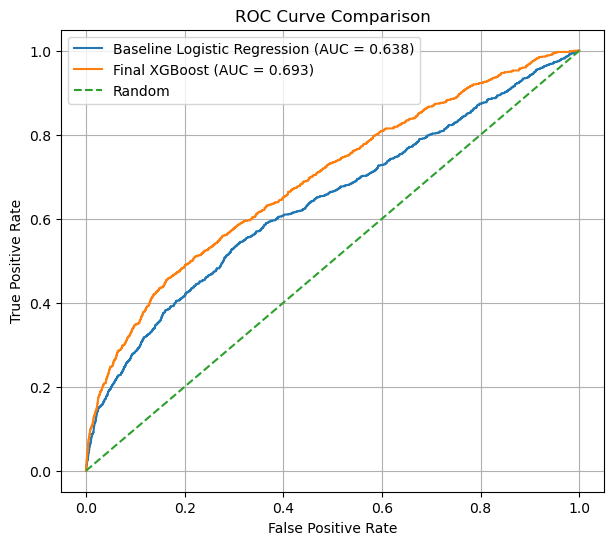

In [17]:
# ==========================================
# ROC curve comparison
# ==========================================
fpr_logreg, tpr_logreg, _ = roc_curve(y_test_text, y_proba_logreg)
fpr_final, tpr_final, _ = roc_curve(y_test_text, y_proba_final)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr_logreg,
    tpr_logreg,
    label=f"Baseline Logistic Regression (AUC = {metrics_logreg['ROC-AUC']:.3f})"
)
plt.plot(
    fpr_final,
    tpr_final,
    label=f"Final XGBoost (AUC = {metrics_final['ROC-AUC']:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


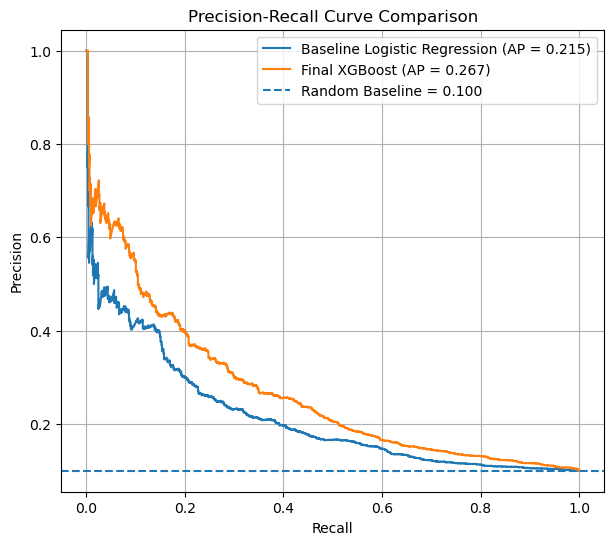

In [18]:
# ==========================================
# Precision-recall curve comparison
# ==========================================
precision_logreg, recall_logreg, _ = precision_recall_curve(y_test_text, y_proba_logreg)
precision_final, recall_final, _ = precision_recall_curve(y_test_text, y_proba_final)
baseline_rate = y_test_text.mean()

plt.figure(figsize=(7, 6))
plt.plot(
    recall_logreg,
    precision_logreg,
    label=f"Baseline Logistic Regression (AP = {metrics_logreg['Average Precision']:.3f})"
)
plt.plot(
    recall_final,
    precision_final,
    label=f"Final XGBoost (AP = {metrics_final['Average Precision']:.3f})"
)
plt.axhline(
    baseline_rate,
    linestyle="--",
    label=f"Random Baseline = {baseline_rate:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


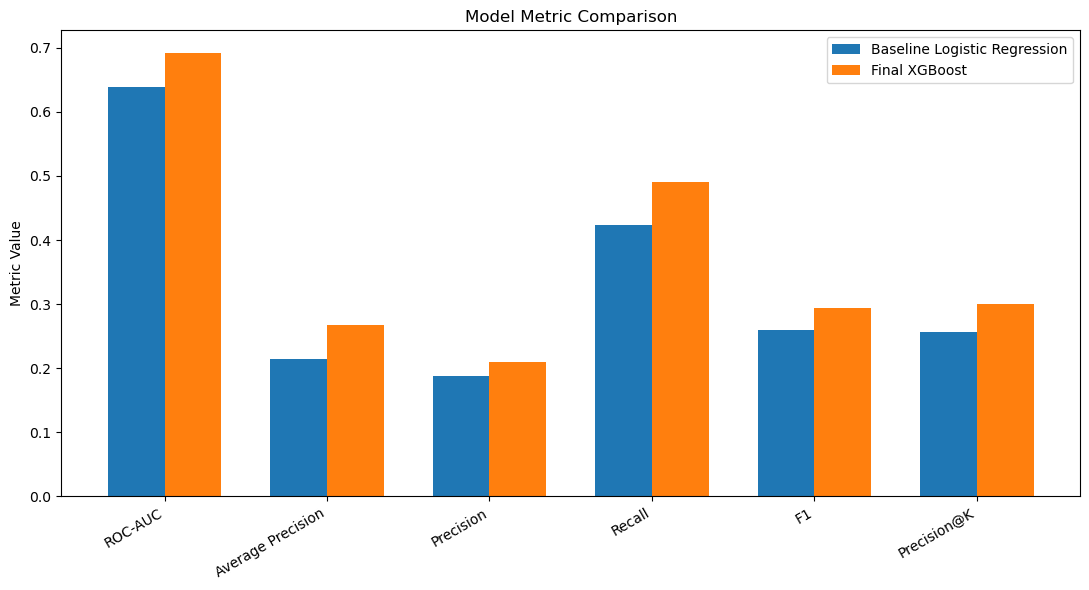

In [19]:
# ==========================================
# Metric bar chart comparison
# ==========================================
plot_metrics = ["ROC-AUC", "Average Precision", "Precision", "Recall", "F1", "Precision@K"]
plot_df = comparison_df[comparison_df["metric"].isin(plot_metrics)].copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(11, 6))
plt.bar(
    x - width / 2,
    plot_df["Baseline Logistic Regression"],
    width,
    label="Baseline Logistic Regression",
)
plt.bar(
    x + width / 2,
    plot_df["Final XGBoost + Sentiment + TF-IDF/SVD"],
    width,
    label="Final XGBoost",
)

plt.xticks(x, plot_df["metric"], rotation=30, ha="right")
plt.ylabel("Metric Value")
plt.title("Model Metric Comparison")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Feature importance and interpretability

The Logistic Regression coefficients show the strongest linear associations from the baseline model. The XGBoost feature importances show which tabular, sentiment, and SVD text components were most used by the final nonlinear model.


In [20]:
# ==========================================
# Baseline Logistic Regression coefficients
# ==========================================
logreg_feature_names = logreg_model.named_steps["preprocess"].get_feature_names_out()
logreg_coefs = logreg_model.named_steps["model"].coef_[0]

logreg_coef_df = pd.DataFrame({
    "feature": logreg_feature_names,
    "coefficient": logreg_coefs,
    "abs_coefficient": np.abs(logreg_coefs),
}).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

display(logreg_coef_df.head(25))


,feature,coefficient,abs_coefficient
0,num__sum_vote_4w,0.484358,0.484358
1,num__max_rating_4w,-0.409305,0.409305
2,num__mean_rating_4w,0.354456,0.354456
3,num__mean_vote_4w,0.260252,0.260252
4,num__vote_per_review_4w,0.260252,0.260252
5,cat__category_Electronics,-0.188506,0.188506
6,num__mean_review_text_len_4w,-0.159299,0.159299
7,num__median_rating_4w,0.131229,0.131229
8,num__std_rating_4w,0.106125,0.106125
9,num__min_rating_4w,-0.092449,0.092449


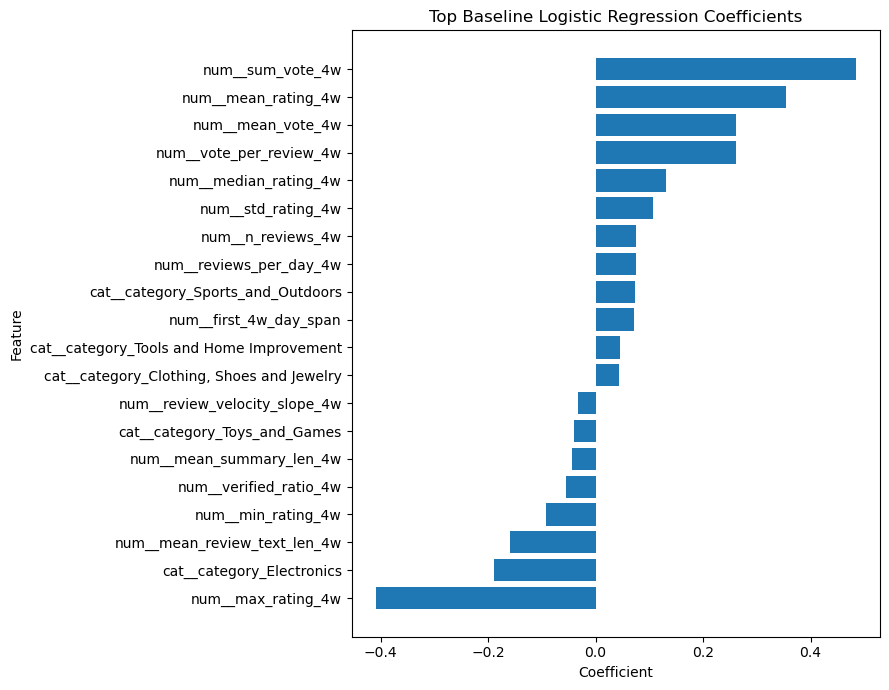

In [21]:
# ==========================================
# Plot top Logistic Regression coefficients
# ==========================================
top_n = 20
top_coef_df = logreg_coef_df.head(top_n).sort_values("coefficient")

plt.figure(figsize=(9, 7))
plt.barh(top_coef_df["feature"], top_coef_df["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Baseline Logistic Regression Coefficients")
plt.tight_layout()
plt.show()


In [22]:
# ==========================================
# Final model feature importances
# ==========================================
tabular_feature_names = xgb_tabular_sentiment_preprocess.get_feature_names_out()
svd_feature_names = np.array([f"svd_text_component_{i+1}" for i in range(X_train_text_svd.shape[1])])
final_feature_names = np.concatenate([tabular_feature_names, svd_feature_names])

final_importance_df = pd.DataFrame({
    "feature": final_feature_names,
    "importance": final_xgb_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(final_importance_df.head(25))


,feature,importance
0,num__sum_vote_4w,0.028108
1,num__mean_vote_4w,0.026146
2,num__mean_review_text_len_4w,0.011898
3,num__n_reviews_4w,0.010332
4,num__review_velocity_slope_4w,0.010091
5,num__first_4w_day_span,0.009463
6,svd_text_component_2,0.009196
7,num__reviews_per_day_4w,0.008895
8,num__verified_ratio_4w,0.008412
9,num__mean_summary_len_4w,0.007797


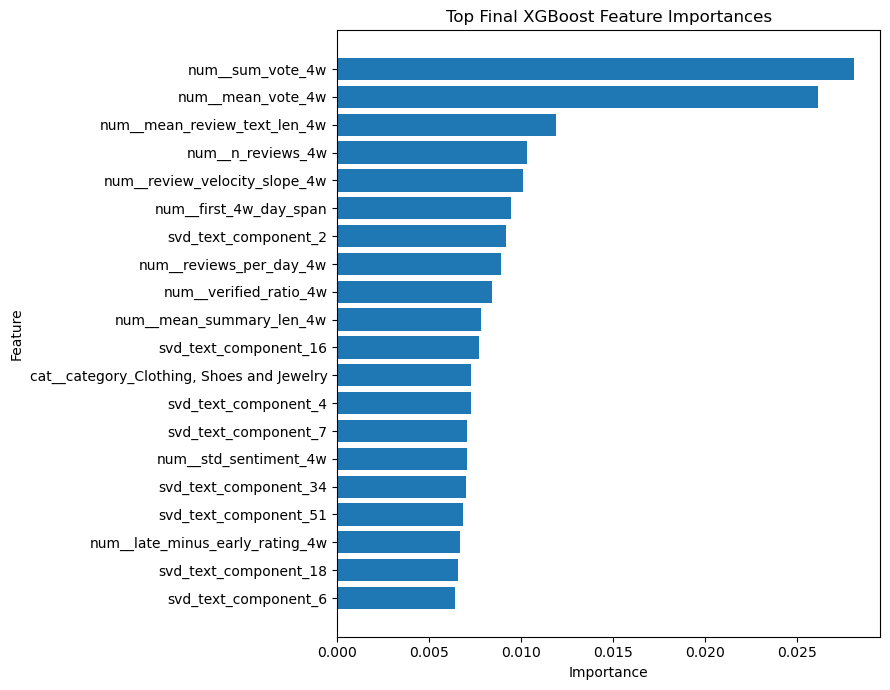

In [23]:
# ==========================================
# Plot top feature importances
# ==========================================
top_n = 20
top_importance_df = final_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(9, 7))
plt.barh(top_importance_df["feature"], top_importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Final XGBoost Feature Importances")
plt.tight_layout()
plt.show()


In [24]:
# ==========================================
# Inspect top TF-IDF terms for important SVD text components
# ==========================================
terms = np.array(tfidf_vectorizer.get_feature_names_out())

important_svd_components = (
    final_importance_df[final_importance_df["feature"].str.startswith("svd_text_component_")]
    .head(5)["feature"]
    .tolist()
)

for feature_name in important_svd_components:
    component_idx = int(feature_name.replace("svd_text_component_", "")) - 1
    component = svd.components_[component_idx]
    top_term_indices = np.argsort(component)[::-1][:12]
    top_terms = terms[top_term_indices]

    print(f"{feature_name}:")
    print(", ".join(top_terms))
    print()


svd_text_component_2:
stars, stars great, stars good, great, stars love, love, stars nice, shoes, good, cute, fit, comfortable

svd_text_component_16:
camera, lens, cute, doll, bag, stars great, great, quality, battery, price, canon, cameras

svd_text_component_4:
toy, fun, game, old, year old, loves, year, kids, play, set, daughter, son

svd_text_component_7:
great, stars great, images, great product, product, video, works great, great price, works, class, price, com images

svd_text_component_34:
doll, price, shirt, water, socks, toy, size, bulbs, great price, bulb, bottle, dolls



## 6. Q2: Early indicators correlated with success

In [25]:
# ==========================================
# Q2 — Correlation of early indicators with success
# ==========================================
# Use interpretable numeric features only: engineered tabular features + sentiment features.
interpretable_feature_cols = feature_cols_num_text

corr_df = model_text_df[interpretable_feature_cols + [target_col]].corr(numeric_only=True)

target_corr_df = (
    corr_df[[target_col]]
    .drop(index=target_col)
    .rename(columns={target_col: "correlation_with_success"})
    .sort_values("correlation_with_success", ascending=False)
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(target_corr_df)


,feature,correlation_with_success
0,sum_vote_4w,0.149646
1,mean_vote_4w,0.128280
2,vote_per_review_4w,0.128280
3,n_reviews_4w,0.088263
4,reviews_per_day_4w,0.088263
5,review_velocity_slope_4w,0.060348
6,first_4w_day_span,0.053461
7,mean_review_text_len_4w,0.040094
8,std_rating_4w,0.027445
9,std_sentiment_4w,0.018074


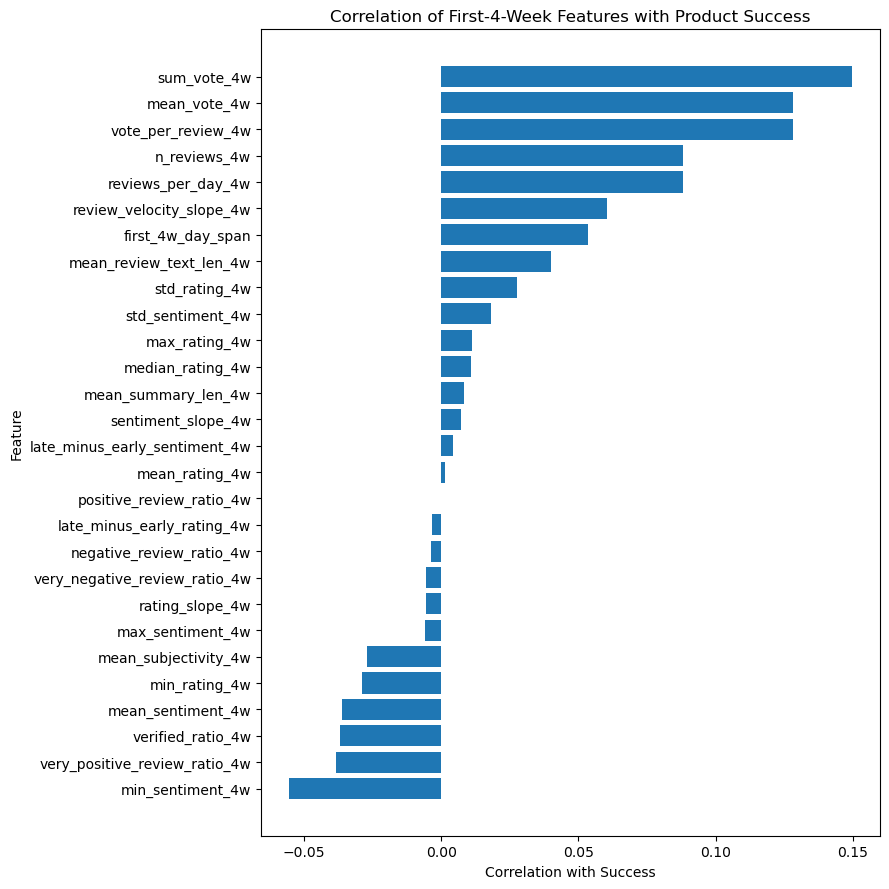

In [26]:
# ==========================================
# Q2 — Plot feature correlations with success
# ==========================================
plot_corr_df = target_corr_df.sort_values("correlation_with_success")

plt.figure(figsize=(9, 9))
plt.barh(plot_corr_df["feature"], plot_corr_df["correlation_with_success"])
plt.xlabel("Correlation with Success")
plt.ylabel("Feature")
plt.title("Correlation of First-4-Week Features with Product Success")
plt.tight_layout()
plt.show()


In [27]:
# ==========================================
# Q2 — Short interpretation helper
# ==========================================
top_n = 5
top_positive_corr = target_corr_df.head(top_n).copy()
top_negative_corr = target_corr_df.tail(top_n).sort_values("correlation_with_success").copy()

print("Top positively correlated early indicators:")
display(top_positive_corr)

print("Top negatively correlated early indicators:")
display(top_negative_corr)

top3_pos = target_corr_df.head(3)["feature"].tolist()
top3_neg = target_corr_df.tail(3)["feature"].tolist()

print("Suggested interpretation:")
print()
print(
    f"The features most positively correlated with long-term success were "
    f"{top3_pos[0]}, {top3_pos[1]}, and {top3_pos[2]}. "
    f"This suggests that early momentum, rating behavior, engagement, and/or sentiment-related signals "
    f"contain useful information about which products eventually become top performers."
)
print()
print(
    f"The most negatively correlated features were "
    f"{top3_neg[0]}, {top3_neg[1]}, and {top3_neg[2]}. "
    f"These features may be associated with weaker early momentum or less stable early product performance."
)
print()
print(
    "Because these are simple pairwise correlations, they should be interpreted as directional signals "
    "rather than causal effects. The final model feature importances provide a complementary view of which "
    "features are useful in combination."
)


Suggested interpretation:

The features most positively correlated with long-term success were sum_vote_4w, mean_vote_4w, and vote_per_review_4w. This suggests that early momentum, rating behavior, engagement, and/or sentiment-related signals contain useful information about which products eventually become top performers.

The most negatively correlated features were verified_ratio_4w, very_positive_review_ratio_4w, and min_sentiment_4w. These features may be associated with weaker early momentum or less stable early product performance.

Because these are simple pairwise correlations, they should be interpreted as directional signals rather than causal effects. The final model feature importances provide a complementary view of which features are useful in combination.


## 8. Text theme analysis: high-performing vs low-performing products

This section extracts interpretable text themes from first-4-week review text. We compare TF-IDF terms for high-performing products (`success_top10 = 1`) against low-performing products (`success_top10 = 0`), both overall and within each product category.

In [28]:
# ==========================================
# Theme analysis setup
# ==========================================
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the same product-level text corpus and success labels already created for the final model.
theme_df = model_text_df[["asin", "category", target_col, "combined_text"]].copy()
theme_df["combined_text"] = theme_df["combined_text"].fillna("").astype(str)

print("Theme analysis dataset shape:", theme_df.shape)
print("Positive rate:", theme_df[target_col].mean())
display(theme_df.head())

,asin,category,success_top10,combined_text
0,5120053351,"Clothing, Shoes and Jewelry",0,Thigh High Lace Top Silicone Stockings Are Com...
1,5120053890,"Clothing, Shoes and Jewelry",0,Best dress I've ever bought online and it's wo...
2,B00001W0GC,"Clothing, Shoes and Jewelry",0,halloween costume As a last minute purchase fo...
3,B000074RL3,"Clothing, Shoes and Jewelry",0,It Works! Finally! A sports bra for larger bus...
4,B0000865II,"Clothing, Shoes and Jewelry",1,Berkshire Extra Wear Lycra Pantyhose - Queen S...


In [29]:
# ==========================================
# Helper: compare TF-IDF terms for high vs low performing products
# ==========================================
def get_success_term_differences(
    df,
    text_col="combined_text",
    label_col=target_col,
    max_features=10000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2),
    stop_words="english"
):
    """
    Returns terms that are more associated with high-performing products
    and low-performing products based on average TF-IDF differences.
    """
    df = df.copy()
    df[text_col] = df[text_col].fillna("").astype(str)

    # Need both classes to compare themes.
    if df[label_col].nunique() < 2:
        return pd.DataFrame(), None, None

    vectorizer = TfidfVectorizer(
        max_features=max_features,
        min_df=min_df,
        max_df=max_df,
        ngram_range=ngram_range,
        stop_words=stop_words
    )

    X_tfidf = vectorizer.fit_transform(df[text_col])
    terms = np.array(vectorizer.get_feature_names_out())

    success_mask = df[label_col].values == 1
    low_perf_mask = df[label_col].values == 0

    success_mean = np.asarray(X_tfidf[success_mask].mean(axis=0)).ravel()
    low_perf_mean = np.asarray(X_tfidf[low_perf_mask].mean(axis=0)).ravel()

    diff = success_mean - low_perf_mean

    term_diff_df = pd.DataFrame({
        "term": terms,
        "high_performing_mean_tfidf": success_mean,
        "low_performing_mean_tfidf": low_perf_mean,
        "difference_high_minus_low": diff,
        "abs_difference": np.abs(diff),
    }).sort_values("difference_high_minus_low", ascending=False).reset_index(drop=True)

    return term_diff_df, vectorizer, X_tfidf


def display_top_theme_terms(term_diff_df, n=20):
    """Display top terms associated with high-performing and low-performing products."""
    print("Terms more associated with HIGH-performing products:")
    display(term_diff_df.head(n))

    print("Terms more associated with LOW-performing products:")
    display(
        term_diff_df.tail(n)
        .sort_values("difference_high_minus_low", ascending=True)
        .reset_index(drop=True)
    )

In [30]:
# ==========================================
# Overall text themes: high vs low performing products
# ==========================================
overall_theme_terms_df, overall_theme_vectorizer, overall_tfidf_matrix = get_success_term_differences(
    theme_df,
    max_features=10000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2)
)

In [31]:
# ==========================================
# Explicitly separate HIGH vs LOW performing terms
# ==========================================

# Terms more associated with HIGH-performing products
high_terms_df = overall_theme_terms_df[
    overall_theme_terms_df["difference_high_minus_low"] > 0
].sort_values("difference_high_minus_low", ascending=False)

# Terms more associated with LOW-performing products
low_terms_df = overall_theme_terms_df[
    overall_theme_terms_df["difference_high_minus_low"] < 0
].sort_values("difference_high_minus_low", ascending=True)

print("Top HIGH-performing terms:")
display(high_terms_df.head(25))

,term,high_performing_mean_tfidf,low_performing_mean_tfidf,difference_high_minus_low,abs_difference
0,game,0.010271,0.006205,0.004066,0.004066
1,toy,0.011160,0.007994,0.003166,0.003166
2,usb,0.007298,0.004207,0.003091,0.003091
3,just,0.022149,0.019297,0.002852,0.002852
4,cable,0.008688,0.005877,0.002811,0.002811
5,old,0.013344,0.010554,0.002790,0.002790
6,water,0.008749,0.006134,0.002615,0.002615
7,light,0.016537,0.013979,0.002559,0.002559
8,drive,0.005984,0.003449,0.002535,0.002535
9,like,0.023687,0.021157,0.002530,0.002530


In [32]:
print("\nTop LOW-performing terms:")
display(low_terms_df.head(25))

,term,high_performing_mean_tfidf,low_performing_mean_tfidf,difference_high_minus_low,abs_difference
9999,stars,0.016407,0.028048,-0.011641,0.011641
9998,stars great,0.002931,0.005784,-0.002852,0.002852
9997,stars good,0.001756,0.004328,-0.002571,0.002571
9996,cute,0.009104,0.011023,-0.001919,0.001919
9995,figure,0.002411,0.004241,-0.001830,0.001830
9994,gift,0.004286,0.006054,-0.001769,0.001769
9993,beautiful,0.004070,0.005786,-0.001716,0.001716
9992,stars nice,0.001385,0.002949,-0.001564,0.001564
9991,stars love,0.002071,0.003576,-0.001505,0.001505
9990,nice,0.017003,0.018372,-0.001369,0.001369


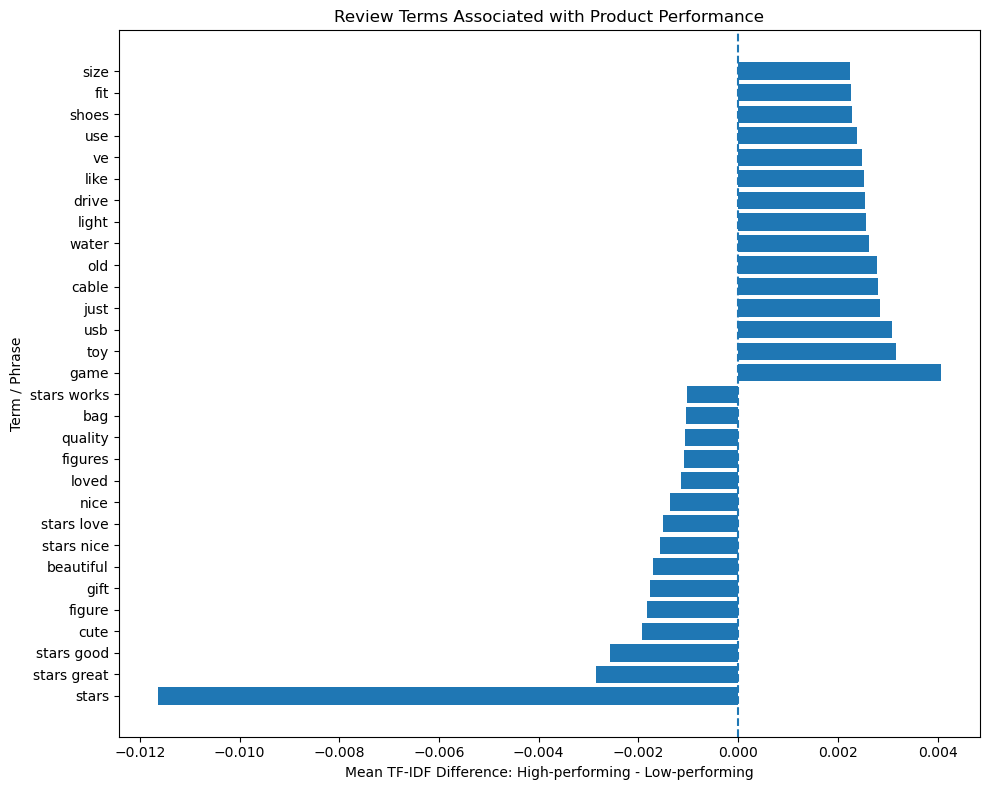

In [33]:
# ==========================================
# Plot overall terms most associated with high and low performance
# ==========================================
n_terms = 15

high_terms = overall_theme_terms_df.head(n_terms).copy()
low_terms = (
    overall_theme_terms_df.tail(n_terms)
    .sort_values("difference_high_minus_low", ascending=True)
    .copy()
)

plot_terms = pd.concat([low_terms, high_terms], axis=0)

plt.figure(figsize=(10, 8))
plt.barh(plot_terms["term"], plot_terms["difference_high_minus_low"])
plt.axvline(0, linestyle="--")
plt.xlabel("Mean TF-IDF Difference: High-performing - Low-performing")
plt.ylabel("Term / Phrase")
plt.title("Review Terms Associated with Product Performance")
plt.tight_layout()
plt.show()

### Category-specific themes

Because review language differs by product type, this section repeats the same high-vs-low TF-IDF comparison within each category.

### Category-specific theme analysis by category

The next cells run the high-performing vs low-performing TF-IDF theme comparison separately for each product category. Splitting this into one cell per category makes it easier to inspect and interpret category-specific language patterns.

In [34]:
# ==========================================
# Helper: display theme terms for one category
# ==========================================
category_theme_results = {}
category_theme_high_low_results = {}

def analyze_category_themes(theme_df, category_name, n=25):
    """
    Runs the high-vs-low TF-IDF theme comparison for one category.
    Stores the full results in category_theme_results so later summary/plot cells still work.
    """
    category_df = theme_df[theme_df["category"] == category_name].copy()

    print("=" * 90)
    print(f"Category: {category_name}")
    print("Number of products:", len(category_df))
    print("Success label counts:")
    display(category_df[target_col].value_counts())

    if category_df.empty:
        print(f"No rows found for category: {category_name}")
        return None, None, None

    if category_df[target_col].nunique() < 2:
        print("Not enough class variation for this category.")
        return None, None, None

    # Use a lower min_df within category so category-specific terms are not filtered out too aggressively.
    category_terms_df, category_vectorizer, category_tfidf = get_success_term_differences(
        category_df,
        max_features=5000,
        min_df=3,
        max_df=0.90,
        ngram_range=(1, 2)
    )

    if category_terms_df.empty:
        print("No terms were extracted for this category.")
        return None, None, None

    high_terms_df = (
        category_terms_df[category_terms_df["difference_high_minus_low"] > 0]
        .sort_values("difference_high_minus_low", ascending=False)
        .reset_index(drop=True)
    )

    low_terms_df = (
        category_terms_df[category_terms_df["difference_high_minus_low"] < 0]
        .sort_values("difference_high_minus_low", ascending=True)
        .reset_index(drop=True)
    )

    category_theme_results[category_name] = category_terms_df
    category_theme_high_low_results[category_name] = {
        "high_terms_df": high_terms_df,
        "low_terms_df": low_terms_df,
        "vectorizer": category_vectorizer,
        "tfidf_matrix": category_tfidf,
    }

    print("\nTop HIGH-performing terms:")
    display(high_terms_df.head(n))

    print("\nTop LOW-performing terms:")
    display(low_terms_df.head(n))

    return category_terms_df, high_terms_df, low_terms_df

In [35]:
# ==========================================
# Check available categories
# ==========================================
print("Available categories:")
for category in sorted(theme_df["category"].dropna().unique()):
    print("-", category)

Available categories:
- Clothing, Shoes and Jewelry
- Electronics
- Sports_and_Outdoors
- Tools and Home Improvement
- Toys_and_Games


In [36]:
# ==========================================
# Theme analysis: Clothing, Shoes and Jewelry
# ==========================================
clothing_terms_df, clothing_high_terms_df, clothing_low_terms_df = analyze_category_themes(
    theme_df,
    category_name="Clothing, Shoes and Jewelry",
    n=25
)

,term,high_performing_mean_tfidf,low_performing_mean_tfidf,difference_high_minus_low,abs_difference
0,stars,0.026620,0.039509,-0.012889,0.012889
1,watch,0.005924,0.011482,-0.005558,0.005558
2,beautiful,0.009280,0.014113,-0.004833,0.004833
3,bracelet,0.001001,0.004456,-0.003455,0.003455
4,coat,0.000765,0.003538,-0.002773,0.002773
5,stars nice,0.002942,0.005683,-0.002741,0.002741
6,loves,0.007982,0.010719,-0.002738,0.002738
7,stars great,0.003716,0.006424,-0.002707,0.002707
8,stars love,0.005988,0.008580,-0.002592,0.002592
9,daughter,0.006171,0.008707,-0.002536,0.002536


In [37]:
# ==========================================
# Theme analysis: Electronics
# ==========================================
electronics_terms_df, electronics_high_terms_df, electronics_low_terms_df = analyze_category_themes(
    theme_df,
    category_name="Electronics",
    n=25
)

,term,high_performing_mean_tfidf,low_performing_mean_tfidf,difference_high_minus_low,abs_difference
0,stars,0.018201,0.026331,-0.008130,0.008130
1,camera,0.019955,0.023696,-0.003741,0.003741
2,stars great,0.002032,0.005409,-0.003377,0.003377
3,stars good,0.003157,0.006020,-0.002863,0.002863
4,strap,0.001602,0.004435,-0.002833,0.002833
5,lens,0.009491,0.012319,-0.002828,0.002828
6,protector,0.003081,0.005677,-0.002596,0.002596
7,bag,0.006094,0.008423,-0.002328,0.002328
8,screen,0.012696,0.014673,-0.001978,0.001978
9,replacement,0.003845,0.005775,-0.001930,0.001930


In [38]:
# ==========================================
# Theme analysis: Sports_and_Outdoors
# ==========================================
sports_terms_df, sports_high_terms_df, sports_low_terms_df = analyze_category_themes(
    theme_df,
    category_name="Sports_and_Outdoors",
    n=25
)

,term,high_performing_mean_tfidf,low_performing_mean_tfidf,difference_high_minus_low,abs_difference
0,stars,0.014962,0.027589,-0.012627,0.012627
1,color,0.002803,0.005891,-0.003088,0.003088
2,great,0.037917,0.040725,-0.002808,0.002808
3,stars good,0.001845,0.004612,-0.002768,0.002768
4,loves,0.002523,0.005211,-0.002688,0.002688
5,nice,0.017604,0.020133,-0.002529,0.002529
6,stars great,0.003787,0.006310,-0.002523,0.002523
7,fun,0.002194,0.004688,-0.002494,0.002494
8,ball,0.004782,0.007205,-0.002423,0.002423
9,son,0.003356,0.005700,-0.002345,0.002345


In [39]:
# ==========================================
# Theme analysis: Tools and Home Improvement
# ==========================================
tools_terms_df, tools_high_terms_df, tools_low_terms_df = analyze_category_themes(
    theme_df,
    category_name="Tools and Home Improvement",
    n=25
)

,term,high_performing_mean_tfidf,low_performing_mean_tfidf,difference_high_minus_low,abs_difference
0,stars,0.013413,0.026297,-0.012884,0.012884
1,good,0.026993,0.030322,-0.003329,0.003329
2,bulb,0.008359,0.011594,-0.003235,0.003235
3,quality,0.015005,0.018158,-0.003153,0.003153
4,stars good,0.001448,0.004472,-0.003024,0.003024
5,stars great,0.003161,0.005764,-0.002603,0.002603
6,fan,0.003285,0.005751,-0.002466,0.002466
7,nice,0.016745,0.019195,-0.002450,0.002450
8,stars works,0.000485,0.002864,-0.002378,0.002378
9,price,0.017004,0.019302,-0.002298,0.002298


In [40]:
# ==========================================
# Theme analysis: Toys_and_Games
# ==========================================
toys_terms_df, toys_high_terms_df, toys_low_terms_df = analyze_category_themes(
    theme_df,
    category_name="Toys_and_Games",
    n=25
)

,term,high_performing_mean_tfidf,low_performing_mean_tfidf,difference_high_minus_low,abs_difference
0,stars,0.016159,0.032998,-0.016839,0.016839
1,figure,0.005748,0.014724,-0.008976,0.008976
2,cute,0.017944,0.024134,-0.006190,0.006190
3,figures,0.004177,0.008557,-0.004381,0.004381
4,doll,0.013101,0.017393,-0.004292,0.004292
5,stars great,0.003331,0.007190,-0.003859,0.003859
6,gift,0.009976,0.013806,-0.003831,0.003831
7,kit,0.002929,0.006687,-0.003758,0.003758
8,collection,0.003963,0.007282,-0.003320,0.003320
9,looks,0.007322,0.010396,-0.003074,0.003074


In [41]:
# ==========================================
# Compact summary table of category-specific themes
# ==========================================
summary_rows = []
terms_per_side = 8

for category, cat_terms_df in category_theme_results.items():
    high_terms = cat_terms_df.head(terms_per_side)["term"].tolist()
    low_terms = (
        cat_terms_df.tail(terms_per_side)
        .sort_values("difference_high_minus_low", ascending=True)["term"]
        .tolist()
    )

    summary_rows.append({
        "category": category,
        "high_performing_associated_terms": ", ".join(high_terms),
        "low_performing_associated_terms": ", ".join(low_terms),
    })

category_theme_summary_df = pd.DataFrame(summary_rows)
display(category_theme_summary_df)

,category,high_performing_associated_terms,low_performing_associated_terms
0,"Clothing, Shoes and Jewelry","fit, shoes, pants, comfortable, bra, wear, siz...","stars, watch, beautiful, bracelet, coat, stars..."
1,Electronics,"usb, drive, cable, mouse, tv, card, wireless, ...","stars, camera, stars great, stars good, strap,..."
2,Sports_and_Outdoors,"water, bottle, work, sling, weight, bottles, c...","stars, color, great, stars good, loves, nice, ..."
3,Tools and Home Improvement,"battery, light, power, switch, unit, don, filt...","stars, good, bulb, quality, stars good, stars ..."
4,Toys_and_Games,"game, toy, old, fun, year, play, year old, baby","stars, figure, cute, figures, doll, stars grea..."


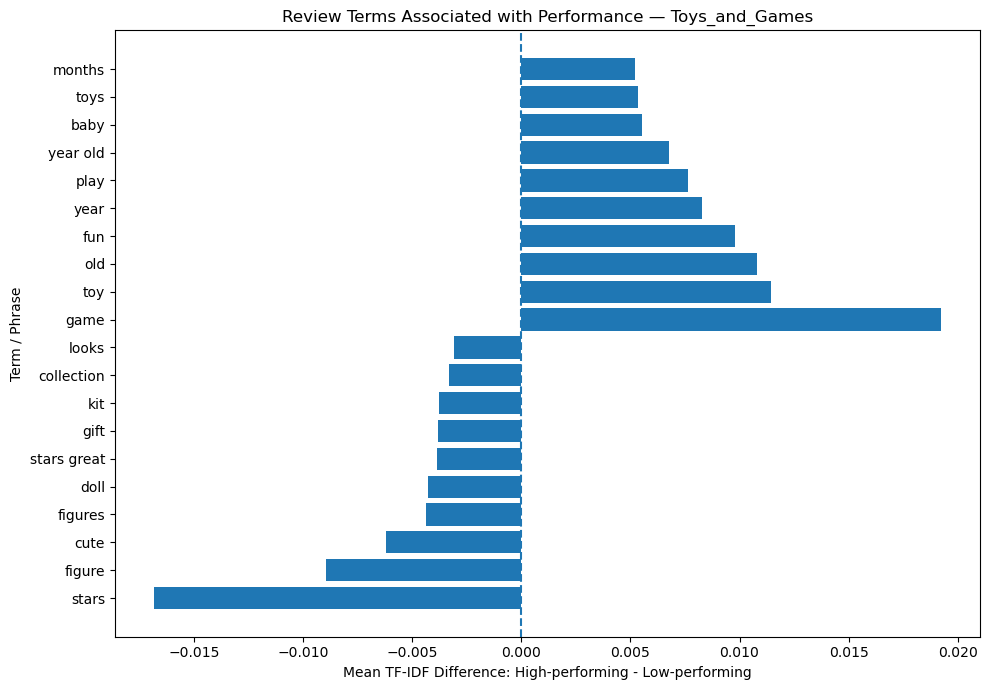

In [53]:
# ==========================================
# Plot themes for one selected category
# ==========================================
# Change this value to inspect another category.
selected_category = sorted(category_theme_results.keys())[4]

cat_terms_df = category_theme_results[selected_category]

n_terms = 10
high_terms = cat_terms_df.head(n_terms).copy()
low_terms = (
    cat_terms_df.tail(n_terms)
    .sort_values("difference_high_minus_low", ascending=True)
    .copy()
)
plot_terms = pd.concat([low_terms, high_terms], axis=0)

plt.figure(figsize=(10, 7))
plt.barh(plot_terms["term"], plot_terms["difference_high_minus_low"])
plt.axvline(0, linestyle="--")
plt.xlabel("Mean TF-IDF Difference: High-performing - Low-performing")
plt.ylabel("Term / Phrase")
plt.title(f"Review Terms Associated with Performance — {selected_category}")
plt.tight_layout()
plt.show()

### Interpretation guide

Positive TF-IDF differences indicate terms that appear more strongly in high-performing products' early reviews. Negative differences indicate terms that appear more strongly in low-performing products' early reviews. These terms are useful for interpreting review themes, but they should not be treated as causal drivers of success.

## 9. Q3: Model consistency across categories

Category-level performance is computed for both the baseline Logistic Regression model and the final XGBoost model. This shows whether the final model improves consistently across product categories.


In [43]:
# ==========================================
# Q3 — Category-level performance for both models
# ==========================================
test_results_logreg = X_test_text.copy()
test_results_logreg["asin"] = asin_test_text.values
test_results_logreg["y_true"] = y_test_text.values
test_results_logreg["y_proba"] = y_proba_logreg
test_results_logreg["y_pred"] = y_pred_logreg

category_metrics_logreg = compute_category_metrics(test_results_logreg)


test_results_final = X_test_text.copy()
test_results_final["asin"] = asin_test_text.values
test_results_final["y_true"] = y_test_text.values
test_results_final["y_proba"] = y_proba_final
test_results_final["y_pred"] = y_pred_final

category_metrics_final = compute_category_metrics(test_results_final)

print("Category-level metrics — Baseline Logistic Regression")
display(category_metrics_logreg)

print("Category-level metrics — Final XGBoost")
display(category_metrics_final)


,category,n_products,positive_rate,roc_auc,avg_precision,precision,recall,f1
0,Toys_and_Games,1941,0.101494,0.733115,0.292040,0.216561,0.517766,0.305389
1,Tools and Home Improvement,1971,0.097920,0.706893,0.264239,0.215190,0.528497,0.305847
2,Sports_and_Outdoors,2051,0.095076,0.685743,0.227187,0.190678,0.461538,0.269865
3,"Clothing, Shoes and Jewelry",2013,0.104322,0.674788,0.293142,0.227500,0.433333,0.298361
4,Electronics,2024,0.101285,0.670811,0.274717,0.203846,0.517073,0.292414


In [44]:
# ==========================================
# Q3 — Category-level ROC-AUC comparison
# ==========================================
category_auc_compare = category_metrics_logreg[["category", "roc_auc"]].merge(
    category_metrics_final[["category", "roc_auc"]],
    on="category",
    suffixes=("_logreg", "_final_xgb"),
)

category_auc_compare = category_auc_compare.sort_values(
    "roc_auc_final_xgb", ascending=False
).reset_index(drop=True)

category_auc_compare["xgb_minus_logreg"] = (
    category_auc_compare["roc_auc_final_xgb"] - category_auc_compare["roc_auc_logreg"]
)

display(category_auc_compare)


,category,roc_auc_logreg,roc_auc_final_xgb,xgb_minus_logreg
0,Toys_and_Games,0.621030,0.733115,0.112086
1,Tools and Home Improvement,0.656096,0.706893,0.050796
2,Sports_and_Outdoors,0.643756,0.685743,0.041987
3,"Clothing, Shoes and Jewelry",0.647152,0.674788,0.027636
4,Electronics,0.651604,0.670811,0.019206


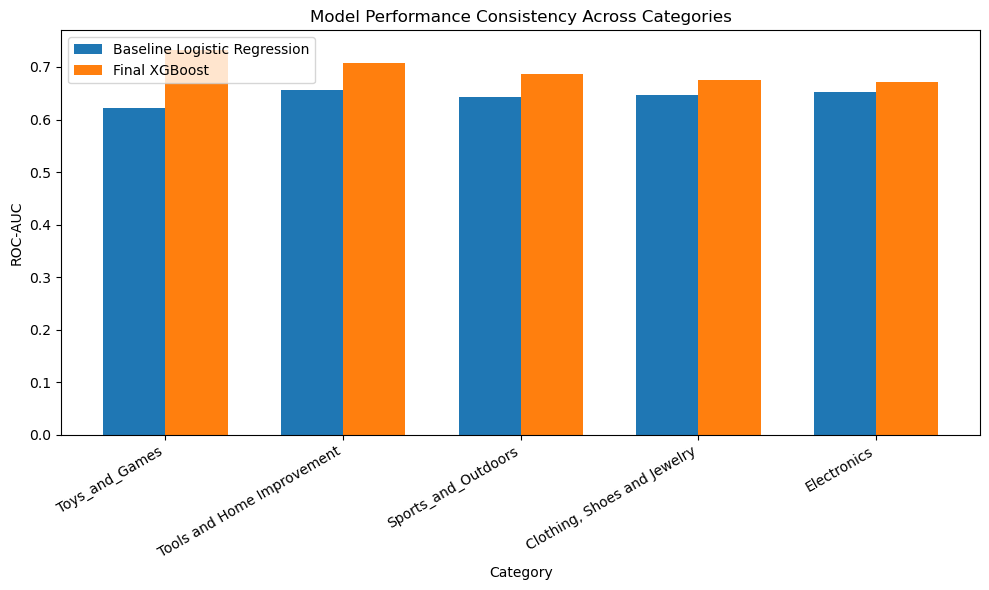

In [45]:
# ==========================================
# Q3 — ROC-AUC by category for both models
# ==========================================
x = np.arange(len(category_auc_compare))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(
    x - width / 2,
    category_auc_compare["roc_auc_logreg"],
    width,
    label="Baseline Logistic Regression",
)
plt.bar(
    x + width / 2,
    category_auc_compare["roc_auc_final_xgb"],
    width,
    label="Final XGBoost",
)

plt.xticks(x, category_auc_compare["category"], rotation=30, ha="right")
plt.ylabel("ROC-AUC")
plt.xlabel("Category")
plt.title("Model Performance Consistency Across Categories")
plt.legend()
plt.tight_layout()
plt.show()


In [46]:
# ==========================================
# Q3 — Summary stats for consistency across categories
# ==========================================
consistency_summary = pd.DataFrame({
    "statistic": ["mean", "std", "min", "max", "range"],
    "Baseline Logistic Regression": [
        category_auc_compare["roc_auc_logreg"].mean(),
        category_auc_compare["roc_auc_logreg"].std(),
        category_auc_compare["roc_auc_logreg"].min(),
        category_auc_compare["roc_auc_logreg"].max(),
        category_auc_compare["roc_auc_logreg"].max() - category_auc_compare["roc_auc_logreg"].min(),
    ],
    "Final XGBoost": [
        category_auc_compare["roc_auc_final_xgb"].mean(),
        category_auc_compare["roc_auc_final_xgb"].std(),
        category_auc_compare["roc_auc_final_xgb"].min(),
        category_auc_compare["roc_auc_final_xgb"].max(),
        category_auc_compare["roc_auc_final_xgb"].max() - category_auc_compare["roc_auc_final_xgb"].min(),
    ],
})

display(consistency_summary)


,statistic,Baseline Logistic Regression,Final XGBoost
0,mean,0.643927,0.694270
1,std,0.013617,0.025840
2,min,0.621030,0.670811
3,max,0.656096,0.733115
4,range,0.035066,0.062305


## Final summary

This notebook compares the original baseline Logistic Regression model against the newest tuned XGBoost model with sentiment and TF-IDF/SVD review text features. The comparison uses the same train/test split, making the evaluation directly comparable.

Key outputs to report:

- The metrics comparison table shows whether the final model improves over the baseline.
- The ROC and precision-recall plots show model discrimination and ranking quality.
- The feature importance and coefficient plots support the question about which early indicators matter.
- The category-level ROC-AUC plot supports the question about consistency across product categories.
